# Timers Implementation Analysis Report

## Methods

In the code, I used LOG_INF statments to print out the values of the toggle intervals for the action LEDs (iv pump and buzzer) and the heartbeat LED. I used k_uptime_ticks() to get the systems representation of time (ticks) and stored the current value and previous value of the toggle for all 3 of the LEDs. Once the value was grabbed, I converted the number of ticks to ms using k_ticks_to_ns_near64(). When the heartbeat and action LEDs were toggled I printed out the value of the time between ticks, subtracting the newest ns value from the old ns value. One note is when I am printing the time between toggles, I multiply the value by 2 because the value I am capturing is half of the full value of the full cycle period. Once these values were printed, I read through the terminal output and captured the values for the varying frequencies and LED to perform analysis on my results.

To run the oscilloscope measurements, I connected the probes to the LED pins in the board and configured the setting to have a sample rate of 5000 samples per second and 50,000 samples were collected (10 seconds of data). The voltage signal for all LEDs ranges from 0V (LED off) - 3.3V (LED on), with some noise seen on both ends. The data was exported to a CSV file, which contains the time-voltage pairings for analysis. 

## Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def load_oscilloscope_data(filename):
    """Load oscilloscope CSV data"""
    df = pd.read_csv(filename, skiprows=1, names=["Time (s)", "Voltage (V)"])
    df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
    df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].str.replace("+", "", regex=False), errors="coerce")
    df = df.dropna()
    return df["Time (s)"].to_numpy(), df["Voltage (V)"].to_numpy()

def load_log_data(filename):
    """Load log data (periods in nanoseconds)"""
    df = pd.read_csv(filename)
    # Convert from nanoseconds to seconds
    periods_s = df["Measurement Period (ns)"].to_numpy() / 1e9
    return periods_s

def detect_led_pulses(time, voltage, threshold=1.5):
    """
    Detect rising edges of LED pulses (OFF to ON transitions)
    Returns the times of rising edges
    """
    # Create binary signal: 1 when voltage > threshold, 0 otherwise
    binary_signal = (voltage > threshold).astype(int)
    
    # Find rising edges (0 -> 1 transitions)
    rising_edges = np.where(np.diff(binary_signal) > 0)[0]
    
    # Get times of rising edges
    edge_times = time[rising_edges]
    
    return edge_times

def calculate_periods(edge_times):
    """Calculate periods between consecutive pulses"""
    if len(edge_times) < 2:
        return np.array([])
    periods = np.diff(edge_times)
    return periods

def calculate_frequency_stats(periods):
    """Calculate frequency statistics and 95% CI"""
    if len(periods) == 0:
        return None
    
    # Calculate frequencies from periods
    frequencies = 1.0 / periods
    
    mean_freq = np.mean(frequencies)
    std_freq = np.std(frequencies, ddof=1)  # Sample std
    ci_95 = 2 * std_freq  # 95% CI for normally distributed data
    
    mean_period = np.mean(periods)
    std_period = np.std(periods, ddof=1)
    
    return {
        'mean_frequency': mean_freq,
        'std_frequency': std_freq,
        'ci_95_frequency': ci_95,
        'mean_period': mean_period,
        'std_period': std_period,
        'ci_95_period': 2 * std_period,
        'frequencies': frequencies,
        'periods': periods
    }

def analyze_oscilloscope(filename, nominal_freq, threshold=1.5):
    """Complete analysis of oscilloscope data"""
    time, voltage = load_oscilloscope_data(filename)
    edge_times = detect_led_pulses(time, voltage, threshold)
    periods = calculate_periods(edge_times)
    stats = calculate_frequency_stats(periods)
    return stats

def analyze_log(filename, nominal_freq):
    """Complete analysis of log data"""
    periods = load_log_data(filename)
    stats = calculate_frequency_stats(periods)
    return stats

def plot_frequency_comparison(nominal_freq, osc_stats, log_stats, led_name):
    """
    Create comparison plot with nominal frequency line and CI bars
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Draw nominal frequency as horizontal line
    ax.axhline(y=nominal_freq, color='black', linestyle='--', linewidth=2, 
               label=f'Nominal ({nominal_freq} Hz)', zorder=1)
    
    x_pos = [1, 2]
    colors = ['#2E86AB', '#A23B72']
    labels = ['Oscilloscope', 'Log Data']
    
    data = [osc_stats, log_stats]
    
    # Determine y-axis limits based on data range
    all_values = []
    for stats in data:
        if stats:
            all_values.append(stats['mean_frequency'] + stats['ci_95_frequency'])
            all_values.append(stats['mean_frequency'] - stats['ci_95_frequency'])
    
    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        y_range = y_max - y_min
        # Add 20% padding to y-axis
        ax.set_ylim(y_min - 0.2*y_range, y_max + 0.2*y_range)
    
    for i, (stats, color, label) in enumerate(zip(data, colors, labels)):
        if stats:
            mean = stats['mean_frequency']
            ci = stats['ci_95_frequency']
            
            # Plot mean as a point
            ax.scatter(x_pos[i], mean, s=200, color=color, zorder=3, 
                      label=f'{label}: {mean:.4f} Hz')
            
            # Plot 95% CI as error bar
            ax.errorbar(x_pos[i], mean, yerr=ci, fmt='none', 
                       ecolor=color, elinewidth=3, capsize=10, capthick=3,
                       zorder=2, alpha=0.7)
            
            # Add text annotation
            ax.text(x_pos[i], mean + ci + 0.02*y_range, 
                   f'±{ci:.4f} Hz\n({((mean-nominal_freq)/nominal_freq)*100:.2f}% error)',
                   ha='center', va='bottom', fontsize=9)
    
    ax.set_xlim(0.5, 2.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Frequency (Hz)', fontsize=12)
    ax.set_title(f'{led_name} - Frequency Accuracy Analysis\n95% Confidence Intervals', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

def plot_histogram_comparison(nominal_freq, osc_stats, log_stats, led_name):
    """
    Create histogram showing distribution of frequency measurements
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Oscilloscope histogram
    if osc_stats:
        ax1.hist(osc_stats['frequencies'], bins=20, color='#2E86AB', 
                alpha=0.7, edgecolor='black')
        ax1.axvline(nominal_freq, color='red', linestyle='--', linewidth=2, 
                   label=f'Nominal: {nominal_freq} Hz')
        ax1.axvline(osc_stats['mean_frequency'], color='darkblue', 
                   linestyle='-', linewidth=2, 
                   label=f'Mean: {osc_stats["mean_frequency"]:.4f} Hz')
        ax1.set_xlabel('Frequency (Hz)', fontsize=11)
        ax1.set_ylabel('Count', fontsize=11)
        ax1.set_title('Oscilloscope Measurements', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # Log data histogram
    if log_stats:
        ax2.hist(log_stats['frequencies'], bins=20, color='#A23B72', 
                alpha=0.7, edgecolor='black')
        ax2.axvline(nominal_freq, color='red', linestyle='--', linewidth=2, 
                   label=f'Nominal: {nominal_freq} Hz')
        ax2.axvline(log_stats['mean_frequency'], color='darkred', 
                   linestyle='-', linewidth=2, 
                   label=f'Mean: {log_stats["mean_frequency"]:.4f} Hz')
        ax2.set_xlabel('Frequency (Hz)', fontsize=11)
        ax2.set_ylabel('Count', fontsize=11)
        ax2.set_title('Log Data Measurements', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    fig.suptitle(f'{led_name} - Frequency Distribution', 
                fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.9)
    return fig

## Heartbeat LED Analysis

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data
timing_data_heart = pd.read_csv('heartbeat_log.csv')

# Print the first few rows of the data
timing_data_heart.head(20)
# print(type(timing_data_heart['Ideal Period (ns)'][0]))


,Ideal Period (ns),Measurement Period (ns)
0,1000000000,1000000000
1,1000000000,1000000000
2,1000000000,1000000000
3,1000000000,1000000000
4,1000000000,1000000000
5,1000000000,1000000000
6,1000000000,1000000000
7,1000000000,1000000000
8,1000000000,1000000000
9,1000000000,1000000000


In [3]:
timing_data_heart.groupby('Ideal Period (ns)')['Measurement Period (ns)'].describe()

,count,mean,std,min,25%,50%,75%,max
Ideal Period (ns),,,,,,,,
1000000000,20.0,1.000000e+09,0.0,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09


In [4]:
import numpy as np
import scipy.stats as sp

timing_data_heart = pd.read_csv('heartbeat_log.csv')

def safe_confidence_interval(x):
    x = pd.to_numeric(x, errors='coerce').dropna()
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = sp.sem(x)
    if sem == 0:  # all values identical
        return (mean, mean)
    ci = sp.t.interval(0.95, n - 1, loc=mean, scale=sem)
    return ci

confidence_interval = timing_data_heart.groupby('Ideal Period (ns)')['Measurement Period (ns)'].apply(safe_confidence_interval)
print(confidence_interval)


Ideal Period (ns)
1000000000    (1000000000.0, 1000000000.0)
Name: Measurement Period (ns), dtype: object


Found 6313 large voltage changes


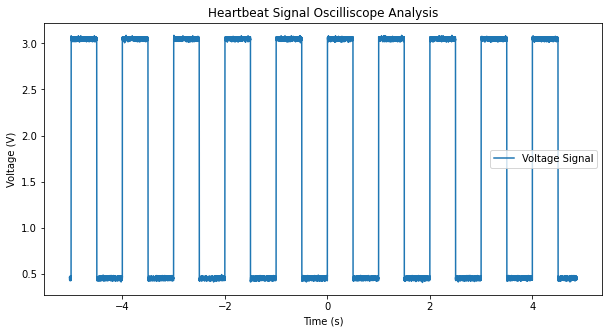

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV, skipping the first descriptive row
df = pd.read_csv("heartbeat.csv", skiprows=1, names=["Time (s)", "Voltage (V)"])

# Clean and convert to numeric
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].str.replace("+", "", regex=False), errors="coerce")

# Drop NaN rows
df = df.dropna()

# Convert to NumPy arrays
time = df["Time (s)"].to_numpy()
voltage = df["Voltage (V)"].to_numpy()

# Check if we have enough data points
if len(time) > 1:
    # Compute differences between consecutive voltages
    dv = np.diff(voltage)
    dt = np.diff(time)
    dv_dt = dv / dt  # rate of voltage change
    
    # Use an absolute threshold instead of std-based
    # Adjust this value based on your signal characteristics
    threshold = 100  # Start with 100 and adjust as needed
    large_changes = np.where(abs(dv_dt) > threshold)[0]
    
    print(f"Found {len(large_changes)} large voltage changes")
else:
    print("Not enough data points to analyze")

# Plot results (without the red dots)
plt.figure(figsize=(10, 5))
plt.plot(time, voltage, label="Voltage Signal")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Heartbeat Signal Oscilliscope Analysis")
plt.legend()
plt.show()

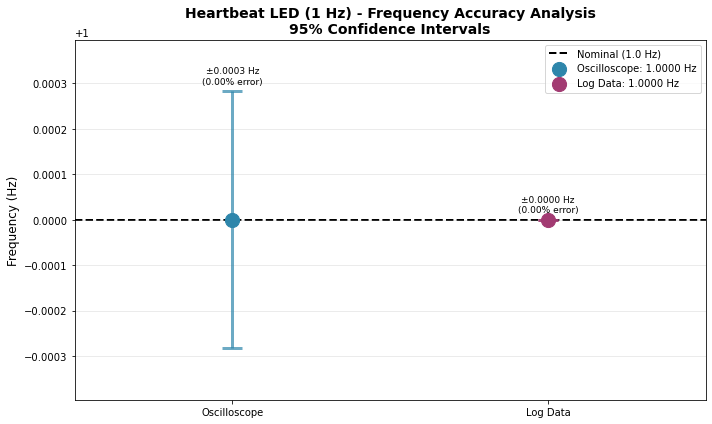

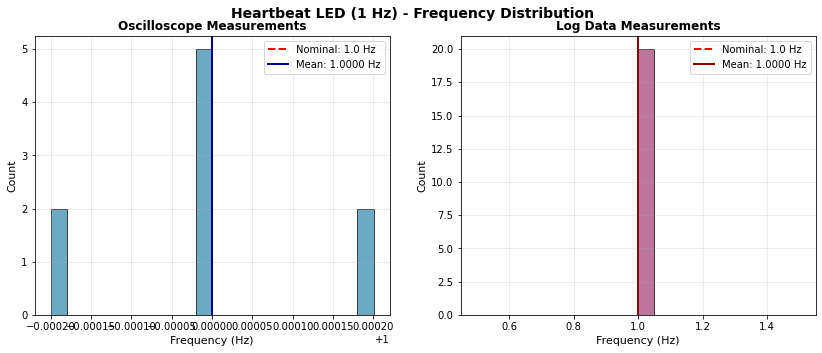

In [6]:
osc_stats_heartbeat = analyze_oscilloscope("heartbeat.csv", 
                                           nominal_freq=1.0, 
                                           threshold=1.5)

log_stats_heartbeat = analyze_log("heartbeat_log.csv", 
                                  nominal_freq=1.0)

if osc_stats_heartbeat and log_stats_heartbeat:
    fig1 = plot_frequency_comparison(1.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Heartbeat LED (1 Hz)")
    fig2 = plot_histogram_comparison(1.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Heartbeat LED (1 Hz)")
    plt.show()

## Action LED 1 Hz Analysis

In [7]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data
timing_data_action_1 = pd.read_csv('action_1hz_log.csv')

# Print the first few rows of the data
timing_data_action_1.head(10)

,Ideal Period (ns),Measurement Period (ns)
0,1000000000,1000000000
1,1000000000,1000000000
2,1000000000,1000000000
3,1000000000,1000000000
4,1000000000,1000000000
5,1000000000,1000000000
6,1000000000,1000000000
7,1000000000,1000000000
8,1000000000,1000000000
9,1000000000,1000000000


In [8]:
timing_data_action_1.groupby('Ideal Period (ns)')['Measurement Period (ns)'].describe()

,count,mean,std,min,25%,50%,75%,max
Ideal Period (ns),,,,,,,,
1000000000,20.0,1.000000e+09,0.0,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09


In [9]:
import numpy as np
import scipy.stats as sp

def safe_confidence_interval(x):
    x = pd.to_numeric(x, errors='coerce').dropna()
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = sp.sem(x)
    if sem == 0:  # all values identical
        return (mean, mean)
    ci = sp.t.interval(0.95, n - 1, loc=mean, scale=sem)
    return ci

confidence_interval = timing_data_action_1.groupby('Ideal Period (ns)')['Measurement Period (ns)'].apply(safe_confidence_interval)
print(confidence_interval)

Ideal Period (ns)
1000000000    (1000000000.0, 1000000000.0)
Name: Measurement Period (ns), dtype: object


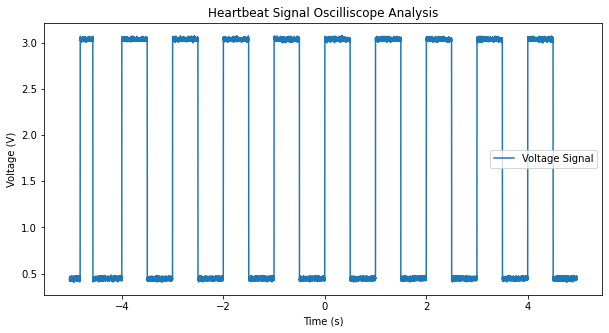

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV, skipping the first descriptive row
df = pd.read_csv("action_1hz.csv", skiprows=1, names=["Time (s)", "Voltage (V)"])

# Clean and convert to numeric
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].str.replace("+", "", regex=False), errors="coerce")

# Drop NaN rows
df = df.dropna()

# Convert to NumPy arrays
time = df["Time (s)"].to_numpy()
voltage = df["Voltage (V)"].to_numpy()

# Compute differences between consecutive voltages
dv = np.diff(voltage)
dt = np.diff(time)
dv_dt = dv / dt  # rate of voltage change

# Identify large voltage jumps with a larger threshold
threshold = np.std(dv_dt) * 10  # Increased from 3 to 10
large_changes = np.where(abs(dv_dt) > threshold)[0]

# Plot results (without the red dots)
plt.figure(figsize=(10, 5))
plt.plot(time, voltage, label="Voltage Signal")
# Removed the scatter plot line
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Heartbeat Signal Oscilliscope Analysis")
plt.legend()
plt.show()

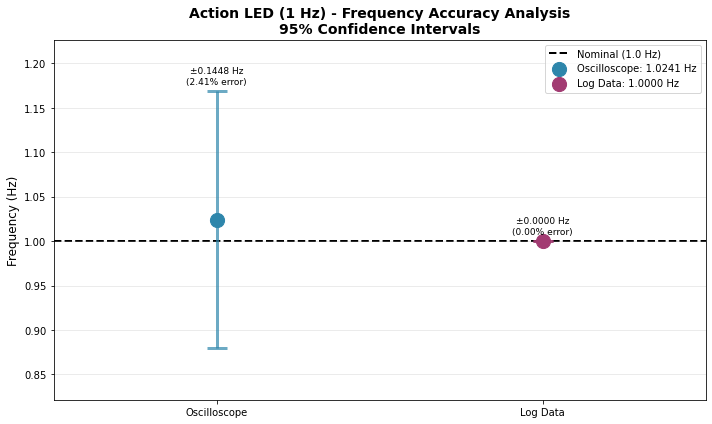

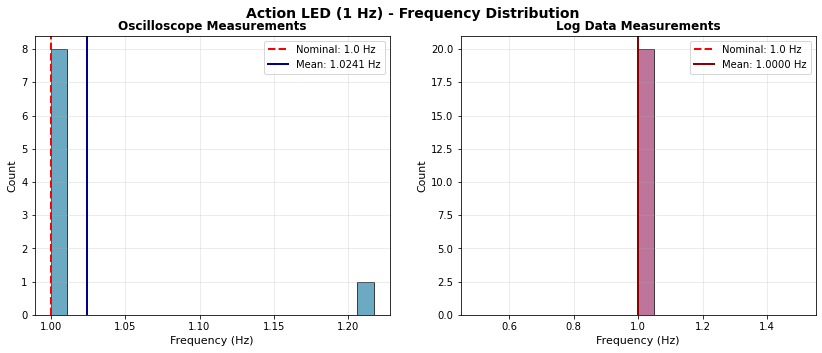

In [11]:
osc_stats_heartbeat = analyze_oscilloscope("action_1hz.csv", 
                                           nominal_freq=1.0, 
                                           threshold=1.5)

log_stats_heartbeat = analyze_log("action_1hz_log.csv", 
                                  nominal_freq=1.0)

if osc_stats_heartbeat and log_stats_heartbeat:
    fig1 = plot_frequency_comparison(1.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (1 Hz)")
    fig2 = plot_histogram_comparison(1.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (1 Hz)")
    plt.show()

## Action LED 2 Hz Log Analysis

In [12]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data
timing_data_action_2 = pd.read_csv('action_2hz_log.csv')

# Print the first few rows of the data
timing_data_action_2.head(10)

,Ideal Period (ns),Measurement Period (ns)
0,500000000,500000000
1,500000000,500000000
2,500000000,500000000
3,500000000,500000000
4,500000000,500000000
5,500000000,500000000
6,500000000,500000000
7,500000000,500000000
8,500000000,500000000
9,500000000,500000000


In [13]:
timing_data_action_2.groupby('Ideal Period (ns)')['Measurement Period (ns)'].describe()

,count,mean,std,min,25%,50%,75%,max
Ideal Period (ns),,,,,,,,
500000000,20.0,500000000.0,0.0,500000000.0,500000000.0,500000000.0,500000000.0,500000000.0


In [14]:
import numpy as np
import scipy.stats as sp

def safe_confidence_interval(x):
    x = pd.to_numeric(x, errors='coerce').dropna()
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = sp.sem(x)
    if sem == 0:  # all values identical
        return (mean, mean)
    ci = sp.t.interval(0.95, n - 1, loc=mean, scale=sem)
    return ci

confidence_interval = timing_data_action_1.groupby('Ideal Period (ns)')['Measurement Period (ns)'].apply(safe_confidence_interval)
print(confidence_interval)

Ideal Period (ns)
1000000000    (1000000000.0, 1000000000.0)
Name: Measurement Period (ns), dtype: object


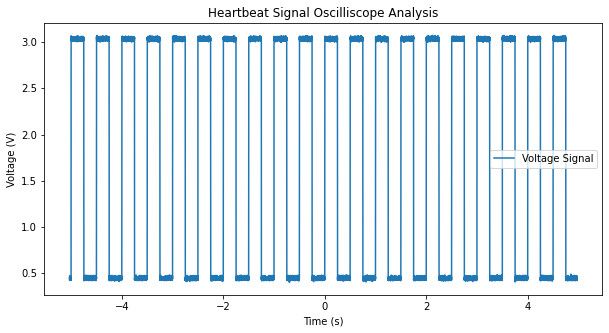

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV, skipping the first descriptive row
df = pd.read_csv("action_2hz.csv", skiprows=1, names=["Time (s)", "Voltage (V)"])

# Clean and convert to numeric
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].str.replace("+", "", regex=False), errors="coerce")

# Drop NaN rows
df = df.dropna()

# Convert to NumPy arrays
time = df["Time (s)"].to_numpy()
voltage = df["Voltage (V)"].to_numpy()

# Compute differences between consecutive voltages
dv = np.diff(voltage)
dt = np.diff(time)
dv_dt = dv / dt  # rate of voltage change

# Identify large voltage jumps with a larger threshold
threshold = np.std(dv_dt) * 10  # Increased from 3 to 10
large_changes = np.where(abs(dv_dt) > threshold)[0]

# Plot results (without the red dots)
plt.figure(figsize=(10, 5))
plt.plot(time, voltage, label="Voltage Signal")
# Removed the scatter plot line
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Heartbeat Signal Oscilliscope Analysis")
plt.legend()
plt.show()

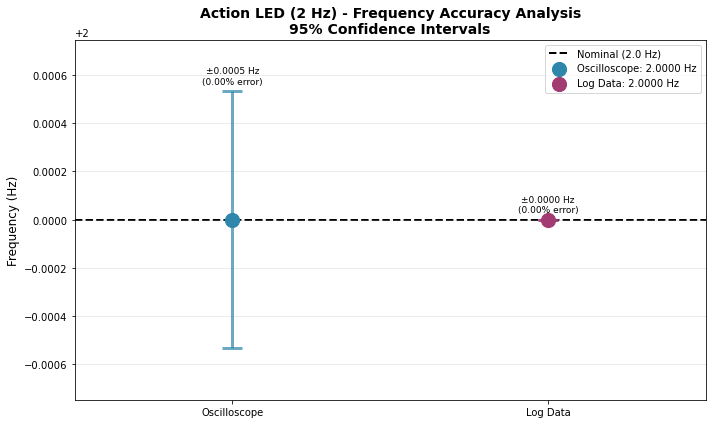

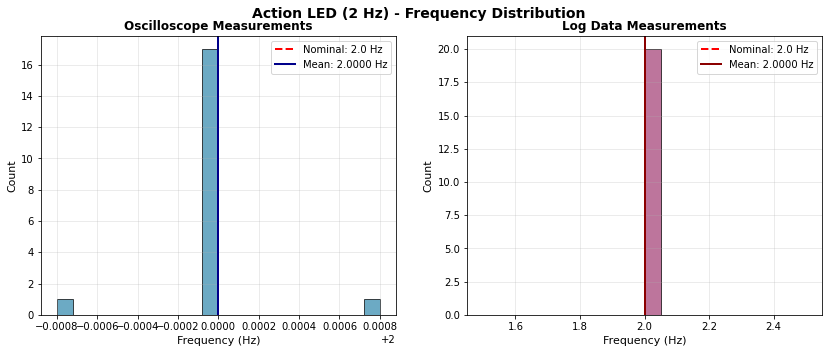

In [16]:
osc_stats_heartbeat = analyze_oscilloscope("action_2hz.csv", 
                                           nominal_freq=2.0, 
                                           threshold=1.5)

log_stats_heartbeat = analyze_log("action_2hz_log.csv", 
                                  nominal_freq=2.0)

if osc_stats_heartbeat and log_stats_heartbeat:
    fig1 = plot_frequency_comparison(2.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (2 Hz)")
    fig2 = plot_histogram_comparison(2.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (2 Hz)")
    plt.show()

## Action LED 5 Hz Log Analysis

In [17]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data
timing_data_action_5 = pd.read_csv('action_5hz_log.csv')

# Print the first few rows of the data
timing_data_action_5.head(10)

,Ideal Period (ns),Measurement Period (ns)
0,200000000,200012206
1,200000000,200012208
2,200000000,200012206
3,200000000,200012208
4,200000000,200012206
5,200000000,200012208
6,200000000,200012206
7,200000000,200012208
8,200000000,200012206
9,200000000,200012208


In [18]:
timing_data_action_5.groupby('Ideal Period (ns)')['Measurement Period (ns)'].describe()

,count,mean,std,min,25%,50%,75%,max
Ideal Period (ns),,,,,,,,
200000000,20.0,200012207.0,1.025978,200012206.0,200012206.0,200012207.0,200012208.0,200012208.0


In [19]:
import numpy as np
import scipy.stats as sp

def safe_confidence_interval(x):
    x = pd.to_numeric(x, errors='coerce').dropna()
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    mean = np.mean(x)
    sem = sp.sem(x)
    if sem == 0:  # all values identical
        return (mean, mean)
    ci = sp.t.interval(0.95, n - 1, loc=mean, scale=sem)
    return ci

confidence_interval = timing_data_action_1.groupby('Ideal Period (ns)')['Measurement Period (ns)'].apply(safe_confidence_interval)
print(confidence_interval)

Ideal Period (ns)
1000000000    (1000000000.0, 1000000000.0)
Name: Measurement Period (ns), dtype: object


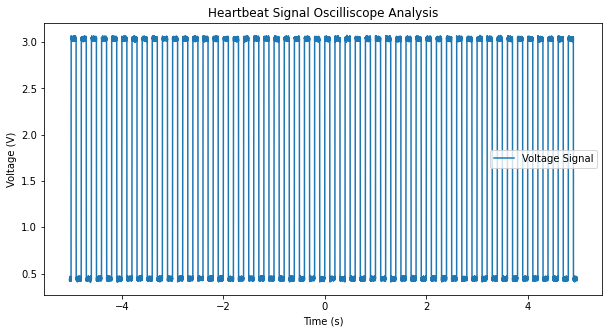

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV, skipping the first descriptive row
df = pd.read_csv("action_5hz.csv", skiprows=1, names=["Time (s)", "Voltage (V)"])

# Clean and convert to numeric
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].str.replace("+", "", regex=False), errors="coerce")

# Drop NaN rows
df = df.dropna()

# Convert to NumPy arrays
time = df["Time (s)"].to_numpy()
voltage = df["Voltage (V)"].to_numpy()

# Compute differences between consecutive voltages
dv = np.diff(voltage)
dt = np.diff(time)
dv_dt = dv / dt  # rate of voltage change

# Identify large voltage jumps with a larger threshold
threshold = np.std(dv_dt) * 10  # Increased from 3 to 10
large_changes = np.where(abs(dv_dt) > threshold)[0]

# Plot results (without the red dots)
plt.figure(figsize=(10, 5))
plt.plot(time, voltage, label="Voltage Signal")
# Removed the scatter plot line
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Heartbeat Signal Oscilliscope Analysis")
plt.legend()
plt.show()

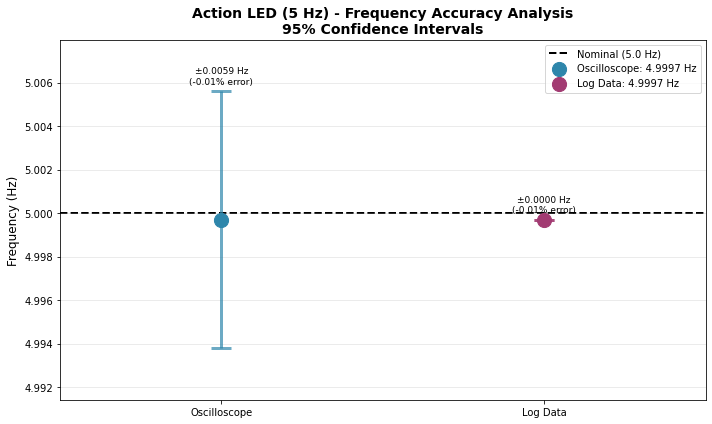

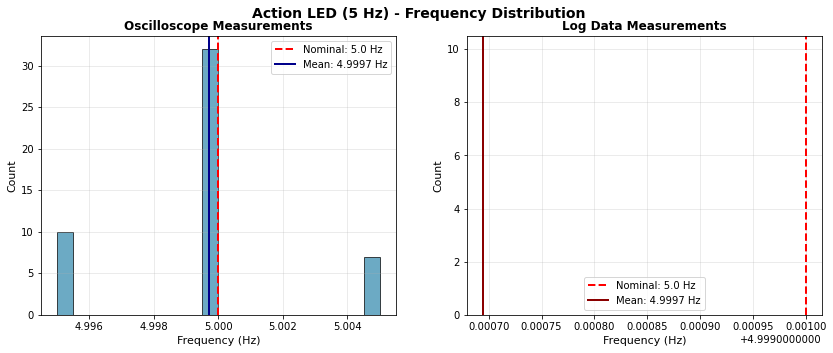

In [21]:
osc_stats_heartbeat = analyze_oscilloscope("action_5hz.csv", 
                                           nominal_freq=5.0, 
                                           threshold=1.5)

log_stats_heartbeat = analyze_log("action_5hz_log.csv", 
                                  nominal_freq=5.0)

if osc_stats_heartbeat and log_stats_heartbeat:
    fig1 = plot_frequency_comparison(5.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (5 Hz)")
    fig2 = plot_histogram_comparison(5.0, osc_stats_heartbeat, log_stats_heartbeat, 
                                     "Action LED (5 Hz)")
    plt.show()

## Discussion & Results

### Confidence Interval

95% confidence intervals for oscilloscope-measured frequencies:
- Heartbeat LED = + / - 0.0003 Hz
- Action LED 1 Hz = + / - 0.1448 Hz
- Action LED 2 Hz = + / - 0.0005 Hz
- Action LED 5 Hz = + / - 0.0059 Hz

95% confidence intervals for LOG measured frequencies: 
- Heartbeat LED = + / - 0 Hz
- Action LED 1 Hz = + / - 0 Hz
- Action LED 2 Hz = + / - 0 Hz
- Action LED 5 Hz = + / - 0 Hz

These results show that the variability between the results is very low, implying that the timing accruacy is very accurate amoung the 4 LED scenarios. Variations in the interval may be due to noise or not long enough data collection. The LOG data shows that the software is executing as intended, while the hardware shows the physical timing on the system-level.

### Confidence Interval Graph

The confidence interval graph is an analysis tool that measures the accuracy and precison of both the LOG statements and oscilliscope measurement methods. To measure the accuracy, I compared the mean frequency to the ideal/nominal values. For all 4 scenarios, heartbeat LED, action LEDs at 1Hz, 2Hz, and 5Hz, their mean values are within a 0.024 range of their nominal values, showing the accuracy of the measured results. Additionally, we don't see much variation with each of the values, showing that I captured consistent measuremnts of the timing accuracy. We can validate that both the hardware and software measurements produce consistent result and reliable timing data. 

### Frequency Distribution Graph

The frequency distribution histogram provides data on the variability and consitency of the timing measurments. A centered distribution indicated that the systems performance is consistent and has minimal variation, while a non-centered distribution suggests variability in the timing of the LEDs. The distribution of all 4 of the scenarios validate the timing of the system, even having a bell shaped distribution as seen in the action LED at 5 Hz, confirms the 95% CI calculation. Based on these results, the LOG and measured data capture the same behavior and the expected behavior of the device. 

### Conclusion

The results show good timing accuracy between the expected values, LOG measured values, and oscilliscope measured values across all LED scenarios. The minimal deviation from the ideal values that the systems timers and functionality are accurate and any deviation can be due to noise and insufficent amounts of data. Analysis will always become more precise with the more data values captured. The close results of the analysis for hardware and software measurements validates that the timing results are accurate and the system is performing as intended, since the results fall within the acceptable tolerance for the ideal values.